# Layers 3–4: The full scaling analysis

Notebooks [00](00_single_cell.ipynb)–[02](02_hp_transfer_law.ipynb) built the pieces: a single
cell, the best learning rate for one cell, and the law $\eta^\star(w,T)$ that predicts it. With
that law every $(N,D)$ cell can be trained near its own optimum, so we can finally read off a
**scaling law**.

A scaling law predicts how the achievable loss falls as you spend more **compute** $C(N,D)$
[FLOPs], and *how to spend it*: at each budget there is an optimal split between **model size**
$N$ (parameters) and **data** $D$ (examples). We use $C=(6N-2dw)\,D$ ($-2dw$ is a small
first-layer correction to the usual $6ND$). The objects of interest are the compute-optimal
frontier $L^\star(C)$ and the allocation $(N^\star(C), D^\star(C))$ that reaches it.

> **Sanity-check the FLOP formula.** A closed form is convenient but architecture-specific. It is good practice to verify it against a real measurement (e.g. PyTorch's `FlopCounterMode`), and if they differ a lot, just **use the measured FLOPs**. We run that check in the [appendix](#flop-appendix).

We extract the frontier **three ways** (the Chinchilla approaches):

1. **Training-curve envelope**, assumption-free; the lower envelope of the loss-vs-compute curves.
2. **IsoFLOP profiles**, at fixed $C$, sweep $N$; the loss-minimising $N$ is $N^\star(C)$.
3. **Parametric fit**, fit $L(N,D)=E+A/N^\alpha+B/D^\beta$ and read the frontier off in closed form.

> **This notebook only visualises and explains.** The grid is trained by a script, each cell at
> the learning rate predicted by the notebook-02 law:
> ```
> python scripts/run_sweep.py        # -> results/sweep_cosine.csv
> ```

## The problem, recapped

(Full setup in [notebook 00](00_single_cell.ipynb).) A fixed, seeded Gaussian teacher defines the
target $y=f_\text{teacher}(x)+\sigma\varepsilon$; the **student** is the MLP we grow. This yields
the additive law $L\approx E + A/N^\alpha + B/D^\beta$, and because the Bayes-optimal predictor is
the teacher we **know the floor exactly**: $E=\sigma^2$. We load the precomputed $(N,D)$ grid.

In [1]:
import os, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

from scaling_laws.sweep import aggregate
from scaling_laws import approaches as ap, plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
meta = json.load(open(os.path.join(RESULTS, "sweep_meta.json")))
E_true = meta["irreducible_loss"]                       # KNOWN floor = sigma^2
agg = aggregate(pd.read_csv(os.path.join(RESULTS, "sweep_cosine.csv")))
print(f"teacher width {meta['problem']['teacher_width']}, noise sigma={meta['problem']['noise_std']}")
print(f"KNOWN irreducible loss  E = sigma^2 = {E_true}")
print(f"grid: {agg['N'].nunique()} model sizes x {agg['D'].nunique()} data sizes, "
      f"N from {agg['N'].min()} to {agg['N'].max()} params")
agg.head()

teacher width 256, noise sigma=0.1
KNOWN irreducible loss  E = sigma^2 = 0.010000000000000002
grid: 13 model sizes x 51 data sizes, N from 345 to 4265985 params


,width,n_hidden,N,D,iso_C,C,batch_size,steps,val_loss,val_loss_std,init_loss
0,8,2,345,1024,0.0,1595392.0,256,4,0.768011,0.050542,1.024455
1,8,2,345,2048,0.0,3190784.0,256,8,0.453767,0.098634,1.024455
2,8,2,345,4096,0.0,6381568.0,256,16,0.295766,0.056638,1.024455
3,8,2,345,8192,0.0,12763136.0,256,32,0.225090,0.011497,1.024455
4,8,2,345,16384,0.0,25526272.0,256,64,0.192331,0.002066,1.024455


## All runs

**Protocol.** Train one student per size $N$ on a ladder of single-pass data budgets $D$, each
cell at its own predicted $\eta^\star$ ([`run_sweep.py`](../scripts/run_sweep.py)), and record the final validation loss.
That table of $(N, D, L)$ is the raw material every approach below works from.

**In code.** [`pl.plot_all_runs(agg)`](../scaling_laws/plotting.py#L44) plots each cell two ways, loss vs **data** $D$ (left: each
model's training curve, flattening at its capacity) and loss vs **compute** $C=(6N-2dw)D$ (right).
Small models win at low compute, larger ones overtake them, and all bend toward the known floor
$E$; the lower-left edge of the compute view is the frontier the three approaches estimate.

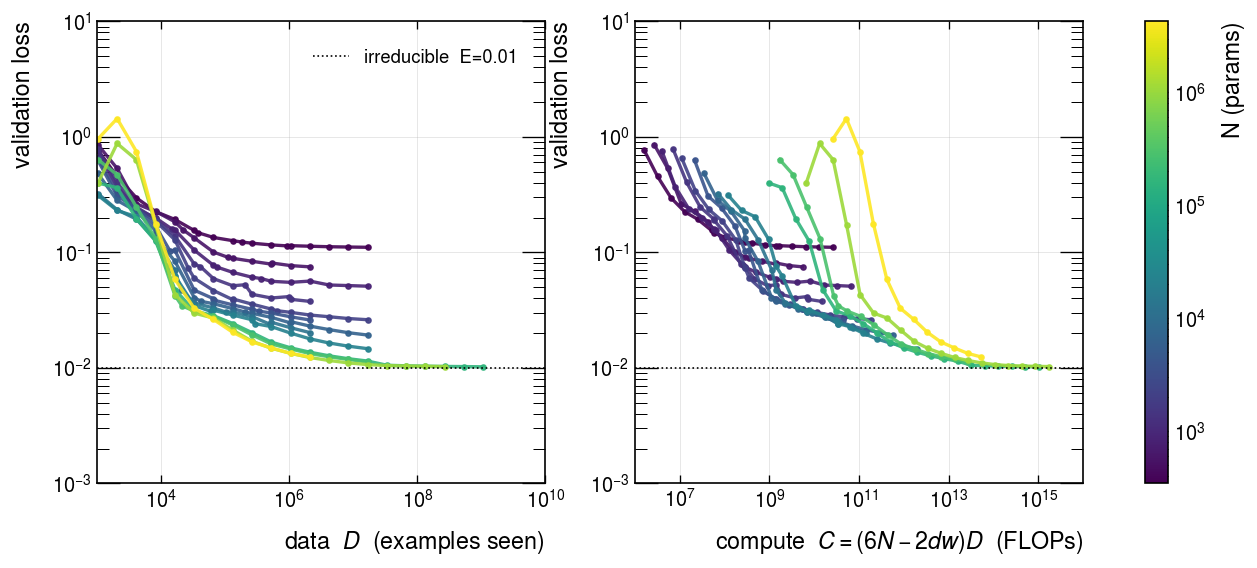

In [2]:
fig = pl.plot_all_runs(agg, irreducible=E_true)
pl.save_figure(fig, "01_overview", outdir=FIGDIR); plt.show()

## Approach 1: training-curve / lower envelope

**Idea.** A cell is compute-optimal if **no cheaper cell reached an equal-or-lower loss**.

**Protocol.** Sort every $(N,D)$ cell by compute $C$; sweep $C$ upward and keep each cell that
sets a new record-low loss. Those record-holders trace the frontier $L^\star(C)$, and their
$(N,D)$ are the optimal allocations, fit $N^\star\!\propto C^{a_N}$ and $D^\star\!\propto C^{a_D}$
(expect $a_N+a_D\approx1$). Nothing is assumed about the loss surface; the staircase look is
just the discrete grid.

**In code.** [`ap.training_curve_envelope(agg)`](../scaling_laws/approaches.py#L51) returns the frontier cells and the fitted
exponents; [`pl.plot_envelope`](../scaling_laws/plotting.py#L73) draws the point cloud, the Pareto staircase, and $N^\star(C)$,
$D^\star(C)$.

Approach 1:  N* ~ C^0.415,   D* ~ C^0.569   (60 frontier cells)


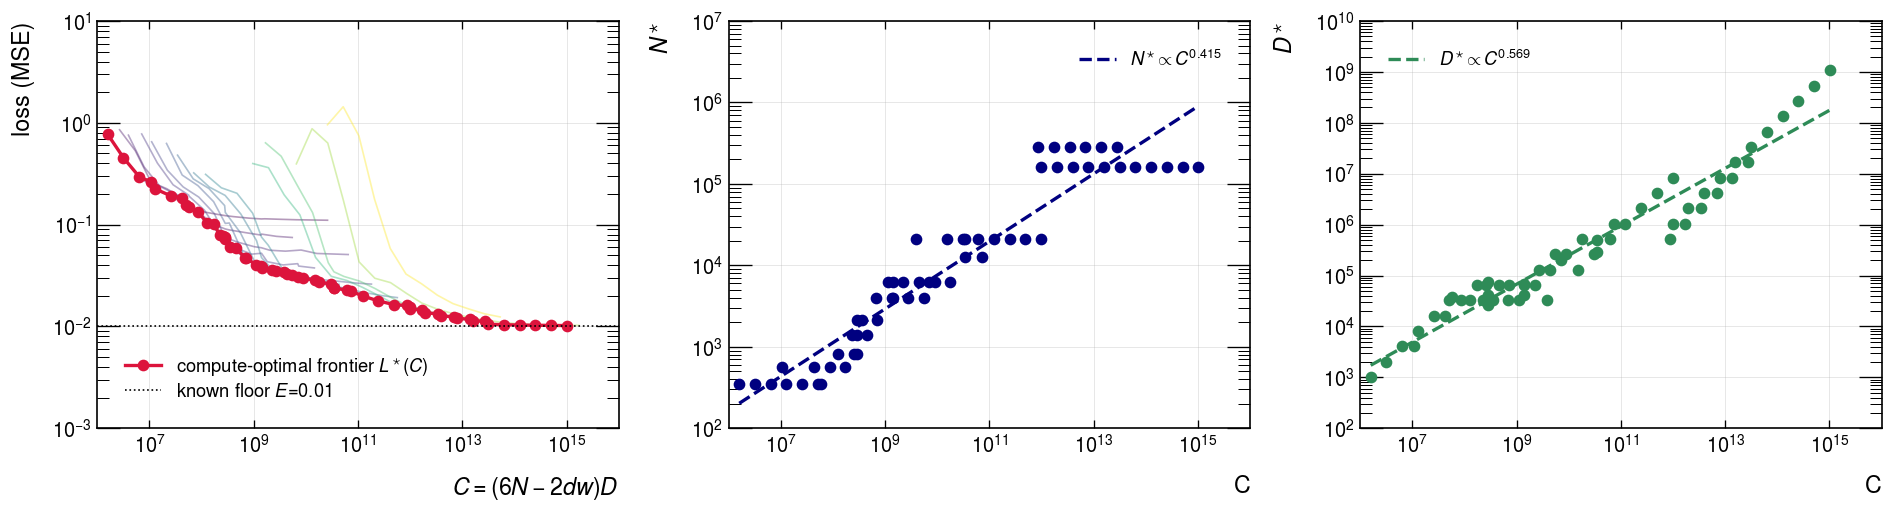

In [3]:
env = ap.training_curve_envelope(agg)
print(f"Approach 1:  N* ~ C^{env.a_N:.3f},   D* ~ C^{env.a_D:.3f}   ({len(env.frontier)} frontier cells)")
fig = pl.plot_envelope(agg, env, irreducible=E_true)
pl.save_figure(fig, "02_approach1_envelope", outdir=FIGDIR); plt.show()

## Approach 2: IsoFLOP profiles

**Idea.** At a *fixed* compute budget there is a best model size, too small underfits, too large
starves for data.

**Protocol.** Pick a ladder of budgets $C$. At each one, **scan model size $N$ along the
iso-compute slice** $D=C/(6N{-}2dw)$ (reading every width's loss off the grid); the slice is
$\cup$-shaped in $\log N$, so fit a parabola and take its **interior** minimum $N^\star(C)$.
Connecting the minima across budgets gives the allocation $N^\star\!\propto C^{a_N}$.

**In code.** [`ap.isoflop_profiles(agg)`](../scaling_laws/approaches.py#L168) builds each slice, trims under-trained tails, fits the
parabola and reads the minimum; [`pl.plot_isoflop`](../scaling_laws/plotting.py#L107) shows the per-budget parabolas (stars = minima)
and the fitted $N^\star, D^\star$.

Approach 2:  N* ~ C^0.558,   D* ~ C^0.411   (5 slices)


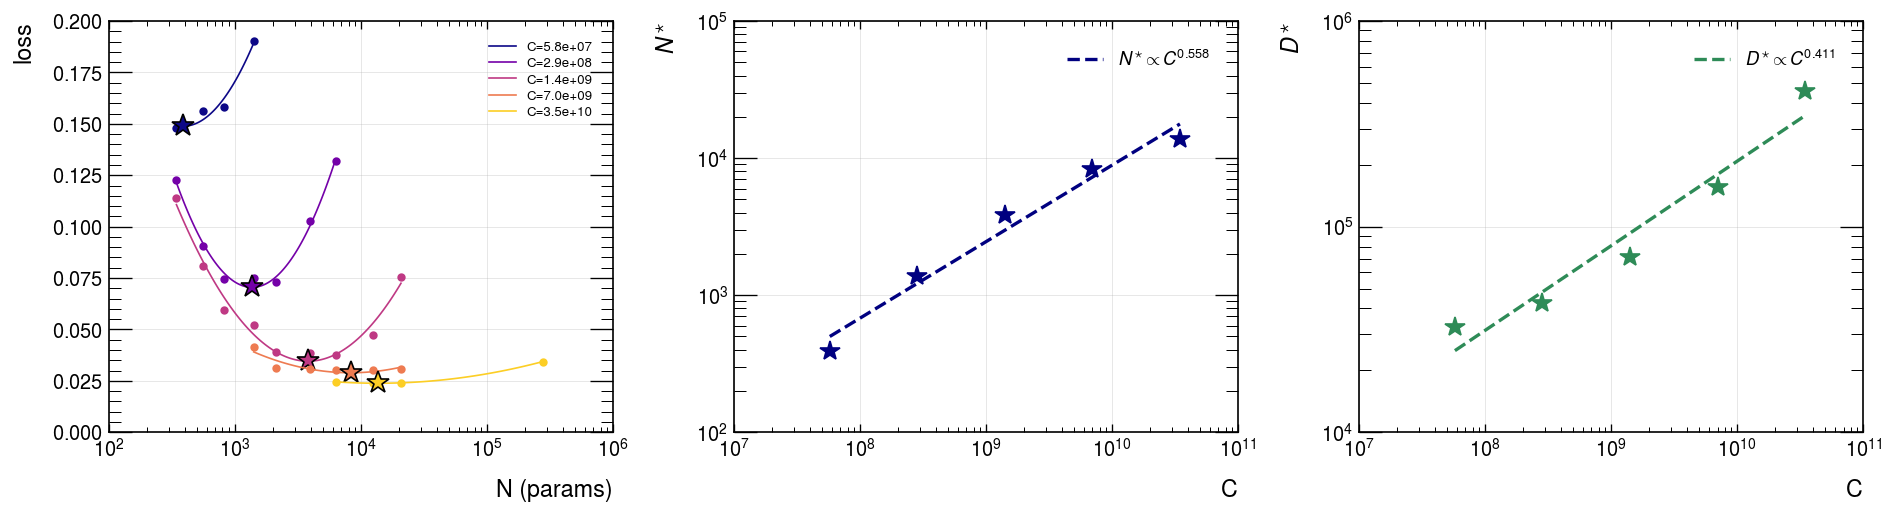

In [4]:
iso = ap.isoflop_profiles(agg, n_targets=10)
print(f"Approach 2:  N* ~ C^{iso.a_N:.3f},   D* ~ C^{iso.a_D:.3f}   ({len(iso.minima)} slices)")
fig = pl.plot_isoflop(iso)
pl.save_figure(fig, "03_approach2_isoflop", outdir=FIGDIR); plt.show()

## Approach 3: parametric (additive "Chinchilla") surface

**Idea.** Don't slice the data, fit the entire loss surface at once.

**Protocol.** Fit $L(N,D)=E+A/N^\alpha+B/D^\beta$ to **all** cells jointly (Huber loss on
log-loss residuals; parameters carried in log-space so $E,A,B>0$). With $(\alpha,\beta)$ the
frontier is closed-form $N^\star\!\propto C^{\beta/(\alpha+\beta)}$, and this is the **only**
approach that also estimates the floor $E$, which we grade against the known $\sigma^2$.

**In code.** [`ap.parametric_fit(agg)`](../scaling_laws/approaches.py#L271) returns $(E,A,B,\alpha,\beta)$ and the derived frontier;
[`pl.plot_parametric`](../scaling_laws/plotting.py#L145) shows the fitted surface in the $(N,D)$ plane with the compute-optimal locus,
plus a fit-quality panel. The allocation exponents are robust; $E$ is the least-constrained.

L(N,D) = 0.0110 + 13.4/N^0.839 + 188/D^0.824
fitted floor E = 0.0110  vs  known E = 0.0100  (off by 10%)
Approach 3:  N* ~ C^0.496,   D* ~ C^0.504


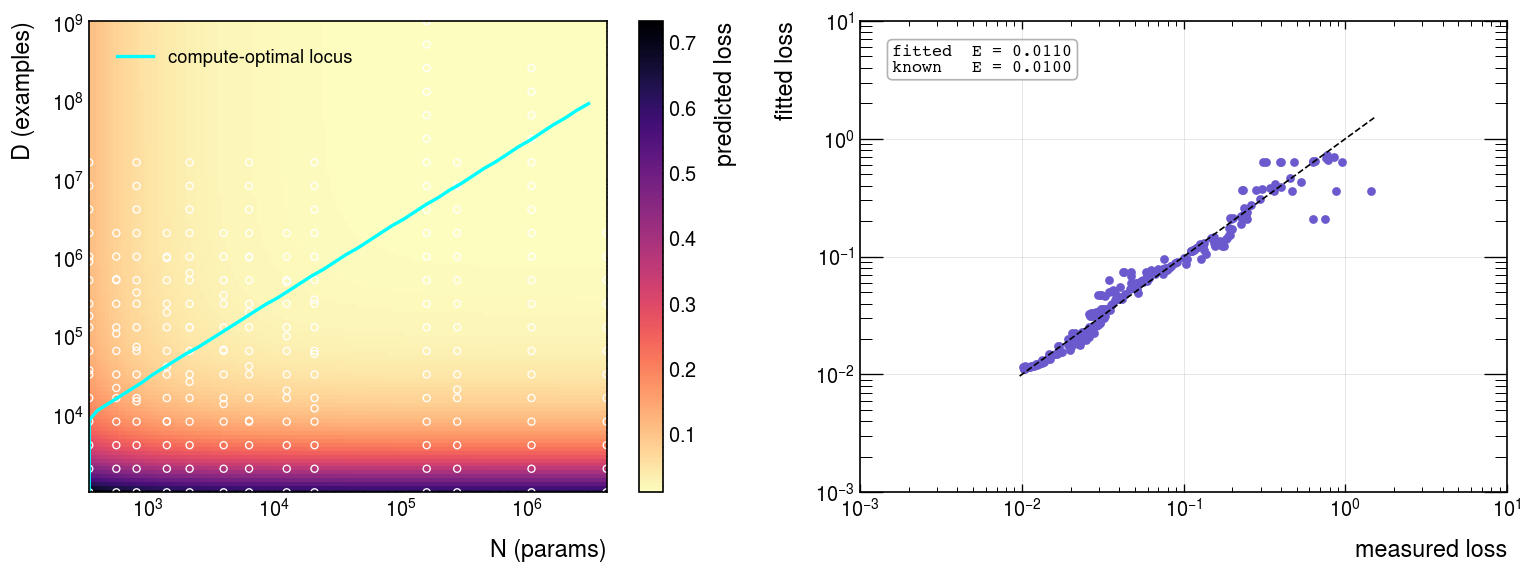

In [5]:
par = ap.parametric_fit(agg)
print(f"L(N,D) = {par.E:.4f} + {par.A:.3g}/N^{par.alpha:.3f} + {par.B:.3g}/D^{par.beta:.3f}")
print(f"fitted floor E = {par.E:.4f}  vs  known E = {E_true:.4f}  "
      f"(off by {100*abs(par.E-E_true)/E_true:.0f}%)")
print(f"Approach 3:  N* ~ C^{par.a_N:.3f},   D* ~ C^{par.a_D:.3f}")
fig = pl.plot_parametric(agg, par, irreducible=E_true)
pl.save_figure(fig, "04_approach3_parametric", outdir=FIGDIR); plt.show()

## Do the three agree?

They should agree on the **allocation** even if they disagree on the floor. The left panel
overlays $N^\star(C)$; the table collects the exponents (and the floor, where defined).

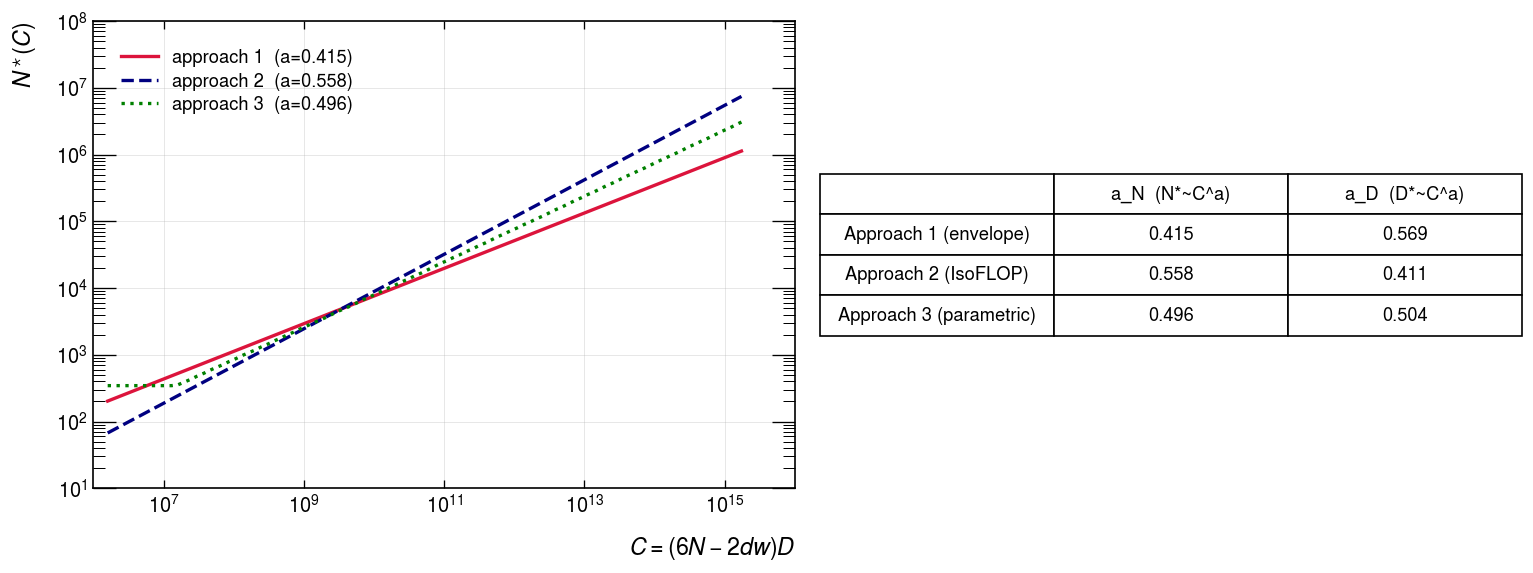

(known floor E = 0.010000000000000002)


,a_N (N*~C^a),a_D (D*~C^a),floor E
1: envelope,0.415,0.569,NaN
2: isoflop,0.558,0.411,NaN
3: parametric,0.496,0.504,0.011


In [6]:
fig = pl.plot_comparison(env, iso, par, (agg["C"].min(), agg["C"].max()))
pl.save_figure(fig, "05_comparison", outdir=FIGDIR); plt.show()

summary = pd.DataFrame({
    "a_N (N*~C^a)": [env.a_N, iso.a_N, par.a_N],
    "a_D (D*~C^a)": [env.a_D, iso.a_D, par.a_D],
    "floor E":      [np.nan,  np.nan,  par.E],
}, index=["1: envelope", "2: isoflop", "3: parametric"])
print(f"(known floor E = {E_true})")
summary.round(3)

## Anatomy of the frontier: three regimes

Write $L^*(C) = E + R(C)$, with $E$ the irreducible loss and $R$ the reducible part. The
frontier is not a single power law:

1. **Fast descent** (low $C$): $R \gg E$, so $L \approx R$ and the frontier falls steeply.
2. **Scaling regime** (mid $C$): $R \to E$; the exponent of $L$ flattens
   ($\gamma\approx-0.14$).
3. **Saturation** (high $C$): $R \ll E$; the frontier flattens onto the floor.

Approach 3 (green) recovers the optimal *allocation*, $a_N$ is set by the ratio of the
$N$- and $D$-terms, and matches the envelope, but not the frontier *loss*: the projected
$L^*(C)$ misses the measured envelope across the scaling regime. The additive form
$L(N,D)=E+A/N^{\alpha}+B/D^{\beta}$, with a single power law per variable, is too rigid to
reproduce all three regimes at once and the fit compromises across them. Use it for
$(N^*, D^*)$, not as a predictor of $L^*(C)$.

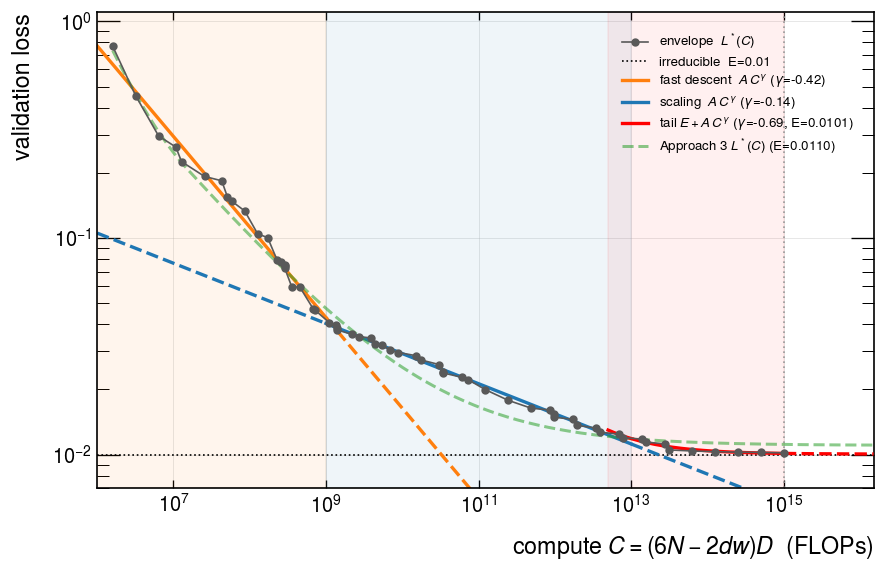

In [7]:
fig = pl.plot_frontier_regimes(env, par, irreducible=E_true)
pl.save_figure(fig, "07_frontier_regimes", outdir=FIGDIR); plt.show()

## Takeaways

- **Three methods, one frontier.** Envelope, IsoFLOP, and parametric fit recover a consistent
  compute-optimal allocation, here close to the equal $\sqrt C$ split: grow $N$ and $D$ **together**.
- **Trust the allocation, less the floor.** $(N^\star,D^\star)$ are robust across methods; the
  fitted $E$ comes from a single method and is more sensitive to the fit range and mis-tuning
  (see the frontier-regimes section above).
- **A scaling law presupposes hyperparameter tuning.** Every cell was launched at its own
  $\eta^\star(w,T)$ (notebooks [00](00_single_cell.ipynb)–[02](02_hp_transfer_law.ipynb)); with one
  fixed LR the wide / long-run cells would be mis-tuned and the exponents biased.

### Caveats
- **Batch size held fixed.** We tune $\eta$ per cell but hold $b=256$; in principle $b$ should be
  **tuned _and scaled_** jointly with $\eta$ (it grows with the horizon, $b^\star\propto\sqrt T$)
 , the natural next step.

### Reproduce
```bash
pip install -e ".[notebook]"        # or: pixi install
python scripts/run_hp_study.py      # ~10 min: calibrate the LR law   (notebook 02)
python scripts/run_sweep.py         # ~45 min: train the (N,D) grid    (--preset quick to smoke-test)
# then run notebooks 00 -> 04 top to bottom; figures export to results/figures/*.pdf
```
The sweep is *incremental*: re-running after extending the data/width range only trains the
genuinely new cells (single-pass cost is dominated by the largest data budget).

## Scaling $N$ by depth

So far $N$ grew by **width** at a fixed depth of 2 hidden layers. [`scripts/run_depth_compare.py`](../scripts/run_depth_compare.py)
adds **1- and 6-layer** families on the same teacher (each with its own LR calibration, since
depth shifts $\eta^\star$) and compares fixed-depth and combined scaling. Deciding how to actually increase the model size of a given architecture (here simply width and depth) is also part of the optimization work one needs to do when properly scaling.

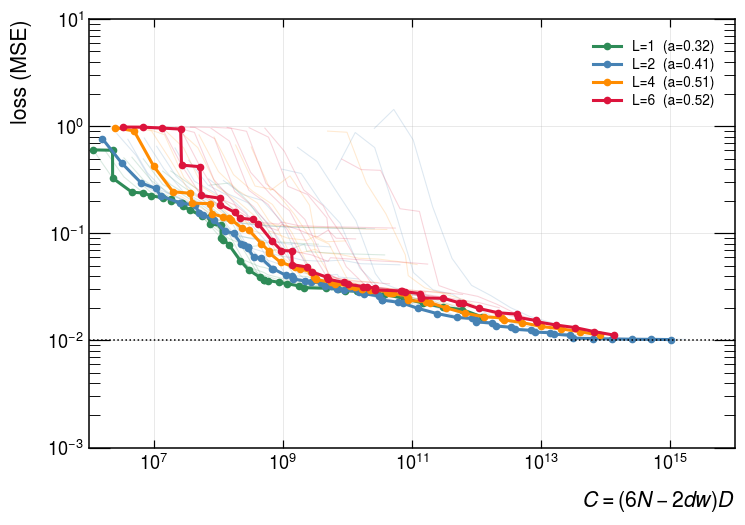

In [8]:
from IPython.display import Image
Image(filename=os.path.join(FIGDIR, 'depth_comparison.png'))

<a id="flop-appendix"></a>
## Appendix: does $C=(6N-2dw)D$ match a real FLOP count?

The formula is a *leading-order* count (matmuls only). Before relying on it, check it against an
actual measurement from PyTorch's `FlopCounterMode`, which traces the ops of a real forward+backward
pass.

**Protocol.** For a ladder of widths, run one fwd+bwd on a batch under `FlopCounterMode`, divide the
total FLOPs by the batch size, and compare the measurement to the closed form
[`flops_per_token`](../scaling_laws/flops.py#L40) $=6N-2dw$ and to the naive $6N$
([`pl.plot_flop_validation`](../scaling_laws/plotting.py#L257) draws it).

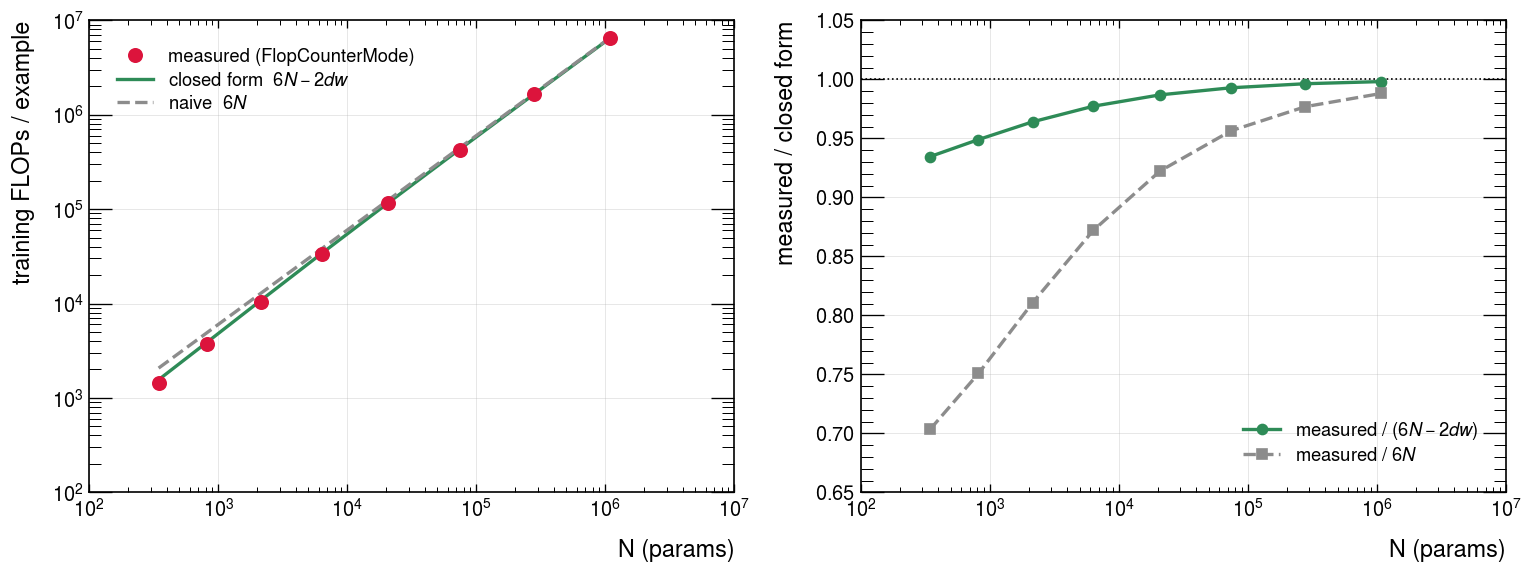

 width       N  measured   formula   naive  meas/(6N-2dw)  meas/6N
     8     345    1456.0    1558.0    2070          0.935    0.703
    16     817    3680.0    3878.0    4902          0.949    0.751
    32    2145   10432.0   10822.0   12870          0.964    0.811
    64    6337   33152.0   33926.0   38022          0.977    0.872
   128   20865  115456.0  116998.0  125190          0.987    0.922
   256   74497  427520.0  430598.0  446982          0.993    0.956
   512  280065 1641472.0 1647622.0 1680390          0.996    0.977
  1024 1084417 6428672.0 6440966.0 6506502          0.998    0.988


In [9]:
import torch
from torch.utils.flop_counter import FlopCounterMode
from scaling_laws.models import make_mlp
from scaling_laws.flops import mlp_param_count, flops_per_token

def measured_flops_per_example(width, n_hidden=2, d=32, B=512):
    net = make_mlp(d, width, n_hidden, 1)
    x = torch.randn(B, d)                 # requires_grad=False -> autograd skips the first
    fc = FlopCounterMode(display=False)   #   layer's input gradient (the -2dw term)
    with fc:
        net(x).square().mean().backward()
    return fc.get_total_flops() / B

flopval = pd.DataFrame([
    dict(width=w, N=(N := mlp_param_count(32, w, 2)),
         measured=measured_flops_per_example(w),
         formula=flops_per_token(N, 32, w), naive=6 * N)
    for w in [8, 16, 32, 64, 128, 256, 512, 1024]
])
fig = pl.plot_flop_validation(flopval)
pl.save_figure(fig, "06_flop_validation", outdir=FIGDIR); plt.show()
print(flopval.assign(**{"meas/(6N-2dw)": (flopval.measured / flopval.formula).round(3),
                        "meas/6N":       (flopval.measured / flopval.naive).round(3)}
                     ).to_string(index=False))